In [13]:
# 在获得了原始数据后，我们就要对数据进行预处理了，这包括3个步骤：过滤标点符号、分词和建立单词表。
from torch import *
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import jieba #结巴分词包
import re #正则表达式的包
from collections import Counter #搜集器，可以让统计词频更简单

In [2]:
#数据文件
good_file='data/good.txt'
bad_file='data/bad.txt'


In [3]:
# 过滤标点符号的函数
def filter_punc(sentence):
    sentence=re.sub("[\s+\.\!\/_,$%^*(+\"\'“”《》?“]+|[+——！，。？、~@#￥%……&*（）：]+", "", sentence)
    return(sentence)

In [4]:
# 接下来扫描文本，建立词袋分辨好评和差评词汇
def Prepare_data(good_file,bad_file,is_filter=True):
    all_words=[]  # collect alll the words
    pos_sentences=[]  # positive 
    neg_sentences=[]  # negative
    with open(good_file,'r',encoding='utf-8') as f:
        for idx,line in enumerate(f):
            if is_filter:
                line=filter_punc(line)  #需要进行过滤标点
            words=jieba.lcut(line)  # 分词
            if len(words)>0:
                all_words+=words
                pos_sentences.append(words)
    print('{0} 包含 {1} 行，{2} 个单词.'.format(good_file, idx+1, len(all_words)))
    count = len(all_words)
    with open(bad_file, 'r', encoding='utf-8') as fr:
        for idx, line in enumerate(fr):
            if is_filter:
                line = filter_punc(line)
                words = jieba.lcut(line)
            if len(words) > 0:
                all_words += words
                neg_sentences.append(words)
    print('{0} 包含 {1} 行，{2} 个单词.'.format(bad_file, idx+1, len(all_words)-count))
    # 通过上述操作读取出了好词和坏词并建立的对应的词库
    diction={}
    cnt = Counter(all_words)
    for word, freq in cnt.items():
        diction[word] = [len(diction), freq]
    print('字典大小：{}'.format(len(diction)))
    return(pos_sentences, neg_sentences, diction)
    
    

In [5]:
# 调用Prepare_data，完成数据处理工作
pos_sentences, neg_sentences, diction = Prepare_data(good_file, bad_file, True)
st = sorted([(v[1], w) for w, v in diction.items()])

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\11485\AppData\Local\Temp\jieba.cache
Loading model cost 0.680 seconds.
Prefix dict has been built successfully.


data/good.txt 包含 8089 行，100839 个单词.
data/bad.txt 包含 5076 行，56070 个单词.
字典大小：7135


In [6]:
# print pos_sentences,neg_sentences,diction
# diction内涵的是{'词'：[idx,'出现次数']}

# 查找单词编码idx
def word2index(word,diction):
    if word in diction:
        idx=diction[word][0]
    else:
        idx=-1  #未找到
    return idx

#  编码找单词
def index2word(index,diction):
    for w,v in diction.item():
        if v[0]==index:
            return(w)
        else:
            return None

In [7]:
# 文本数据向量化，定义函数sentence2vec
def sentence2vec(sentence,dictionary):
    vector=np.zeros(len(dictionary))
    for w in sentence:
        vector[w]+=1
    return(1.0 * vector / len(sentence))

In [8]:
# 遍历所有句子，将每一个单词映射成编码
dataset = [] # 数据集
labels = [] # 标签
sentences = [] # 原始句子，用于调试
# 处理正面评论
for sentence in pos_sentences:
    new_sentence = []
    for l in sentence:
        if l in diction:
            new_sentence.append(word2index(l, diction))
    dataset.append(sentence2vec(new_sentence, diction))
    labels.append(0) #正标签为0
    sentences.append(sentence)

# 处理负面评论
for sentence in neg_sentences:
    new_sentence = []
    for l in sentence:
        if l in diction:
            new_sentence.append(word2index(l, diction))
    dataset.append(sentence2vec(new_sentence, diction))
    labels.append(1) # 负标签为1
    sentences.append(sentence)

# 打乱所有数据的顺序，形成数据集
# indices为所有数据下标的排列
indices = np.random.permutation(len(dataset))

# 根据打乱的下标，重新生成数据集dataset、标签集labels，以及对应的原始句子sentences
dataset = [dataset[i] for i in indices]
labels = [labels[i] for i in indices]
sentences = [sentences[i] for i in indices]

In [9]:
# 将数据集划分为三个，训练集train、验证集val、测试集test，通常情况下是10：1：1
# 验证集的存在是为了检验是否出现了过拟合的情况，需要减少模型的超参数或者提高数据量，从而提升模型的泛化能力
# 首先，在训练模型的时候，是不使用校验集的。
# 其次，在一组超参数下，当我们训练好模型之后，可以利用校验集的数据来测试模型的表现，如果误差与训练数据同样低或差不多，就说明模型的泛化能力很强，否则就说明出现了过拟合的现象
# 可以通过改变超参数、增加dropout层（后面会介绍）或者增加训练数据等方式来避免过拟合
# 训练集用于训练参数，校验集用于调整网络的超参数，比如网络结构、学习率等，测试集用于测试模型的能力。
# 将整个数据集划分为训练集、校验集和测试集，其中校验集和测试集的大小都是整个数据集的十分之一
test_size = int(len(dataset)//10)
train_data = dataset[2 * test_size :]
train_label = labels[2 * test_size :]

valid_data = dataset[: test_size]
valid_label = labels[: test_size]

test_data = dataset[test_size : 2 * test_size]
test_label = labels[test_size : 2 * test_size]

In [10]:
#接下来构建神经网络,7133——>10——>2
# 一个简单的前馈神经网络，共3层
# 第一层为线性层，加一个非线性ReLU激活函数，第二层为线性层，中间有10个隐含神经元
# 输入维度为词典的大小：每一条评论的词袋模型
model = nn.Sequential(
    nn.Linear(len(diction), 10),
    nn.ReLU(),
    nn.Linear(10, 2),
    nn.LogSoftmax(dim=1),
)
def rightness(predictions, labels):
    """计算预测错误率的函数，其中predictions是模型给出的一组预测结果，batch_size行num_classes列的矩阵，labels是数据之中的正确答案"""
    pred = torch.max(predictions.data, 1)[1] # 对于任意一行（一个样本）的输出值的第1个维度，求最大，得到每一行的最大元素的下标
    rights = pred.eq(labels.data.view_as(pred)).sum() #将下标与labels中包含的类别进行比较，并累计得到比较正确的数量
    return rights, len(labels) #返回正确的数量和这一次一共比较了多少元素

In [17]:
# ReLU这个函数在输入大于0的时候完全是一个恒等函数，相当于没有完成任何计算，因此，与传统的sigmoid函数相比，它具有计算快、方便反向误差传播等优良特征。
# 同时，由于它在0的位置分成了两个不连续的部分，因此它具备与sigmoid函数同样的非线性特征。该函数特别适合用在深度的前馈神经网络中，计算效果比sigmoid函数好得多。
# 损失函数为交叉熵
cost = torch.nn.NLLLoss()
# 优化算法为Adam，可以自动调节学习率
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
records = []

#循环10个Epoch
losses = []
for epoch in range(0,10):
    for i, data in enumerate(zip(train_data, train_label)):
        x, y = data
        
        # 需要将输入的数据进行适当的变形，主要是要多出一个batch_size的维度，也即第一个为1的维度
        x = torch.tensor(x, requires_grad = True, dtype = torch.float).view(1,-1)
        # x的尺寸：batch_size=1, len_dictionary
        # 标签也要加一层外衣以变成1*1的张量
        y = torch.tensor(np.array([y]), dtype = torch.long)
        # y的尺寸：batch_size=1, 1
        
        # 清空梯度
        optimizer.zero_grad()
        # 模型预测
        predict = model(x)
        # 计算损失函数
        loss = cost(predict, y)
        # 将损失函数数值加入到列表中
        losses.append(loss.data.numpy())
        # 开始进行梯度反传
        loss.backward()
        # 开始对参数进行一步优化
        optimizer.step()
        
        # 每隔3000步，跑一下校验数据集的数据，输出临时结果
        if i % 3000 == 0:
            val_losses = []
            rights = []
            # 在所有校验数据集上实验
            for j, val in enumerate(zip(valid_data, valid_label)):
                x, y = val
                x = torch.tensor(x, requires_grad = True, dtype = torch.float).view(1,-1)
                y = torch.tensor(np.array([y]), dtype = torch.long)
                predict = model(x)
                # 调用rightness函数计算准确度
                right = rightness(predict, y)
                rights.append(right)
                loss = cost(predict, y)
                val_losses.append(loss.data.numpy())
                
            # 将校验集合上面的平均准确度计算出来
            right_ratio = 1.0 * np.sum([i[0] for i in rights]) / np.sum([i[1] for i in rights])
            print('第{}轮，训练损失：{:.2f}, 校验损失：{:.2f}, 校验准确率: {:.2f}'.format(epoch, np.mean(losses),
                                                                        np.mean(val_losses), right_ratio))
            records.append([np.mean(losses), np.mean(val_losses), right_ratio])
            
print('End of training')

C:\Users\11485\AppData\Local\Temp\ipykernel_24124\4275302802.py:11: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  for epoch in range(0,10):


第0.0轮，训练损失：0.70, 校验损失：0.69, 校验准确率: 0.61
第0.0轮，训练损失：0.35, 校验损失：0.28, 校验准确率: 0.92
第0.0轮，训练损失：0.31, 校验损失：0.28, 校验准确率: 0.91
第0.0轮，训练损失：0.31, 校验损失：0.26, 校验准确率: 0.92
第1.0轮，训练损失：0.31, 校验损失：0.25, 校验准确率: 0.92
第1.0轮，训练损失：0.29, 校验损失：0.26, 校验准确率: 0.92
第1.0轮，训练损失：0.28, 校验损失：0.27, 校验准确率: 0.92
第1.0轮，训练损失：0.27, 校验损失：0.25, 校验准确率: 0.92
第2.0轮，训练损失：0.27, 校验损失：0.25, 校验准确率: 0.92
第2.0轮，训练损失：0.26, 校验损失：0.26, 校验准确率: 0.92
第2.0轮，训练损失：0.26, 校验损失：0.27, 校验准确率: 0.92
第2.0轮，训练损失：0.25, 校验损失：0.25, 校验准确率: 0.92
第3.0轮，训练损失：0.25, 校验损失：0.26, 校验准确率: 0.92
第3.0轮，训练损失：0.25, 校验损失：0.27, 校验准确率: 0.92
第3.0轮，训练损失：0.24, 校验损失：0.28, 校验准确率: 0.92
第3.0轮，训练损失：0.24, 校验损失：0.26, 校验准确率: 0.92
第4.0轮，训练损失：0.24, 校验损失：0.27, 校验准确率: 0.92
第4.0轮，训练损失：0.23, 校验损失：0.28, 校验准确率: 0.92
第4.0轮，训练损失：0.23, 校验损失：0.29, 校验准确率: 0.92
第4.0轮，训练损失：0.23, 校验损失：0.26, 校验准确率: 0.91
第5.0轮，训练损失：0.23, 校验损失：0.27, 校验准确率: 0.91
第5.0轮，训练损失：0.23, 校验损失：0.28, 校验准确率: 0.92
第5.0轮，训练损失：0.22, 校验损失：0.30, 校验准确率: 0.91
第5.0轮，训练损失：0.22, 校验损失：0.27, 校验准确率: 0.91
第6.0轮，训练损失：0.22, 校验损失：0.28, 校验准确率: 0.91


In [18]:
%config IPCompleter.greedy=True

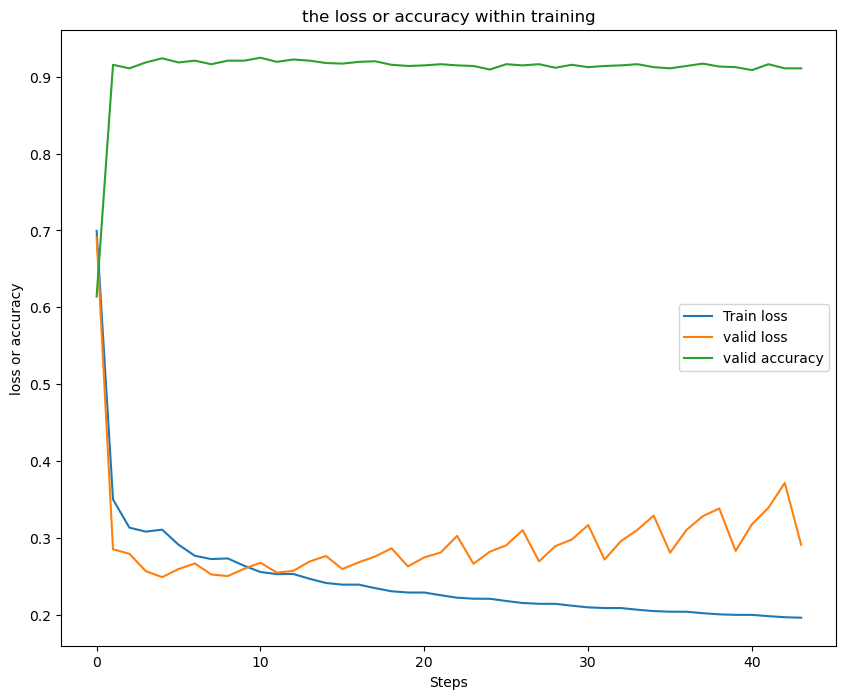

In [26]:
# 绘制误差曲线
import matplotlib.pyplot as plt
a=[i[0] for i in records]
b=[i[1] for i in records]
c=[i[2] for i in records]
plt.figure(figsize=(10,8))
plt.title('the loss or accuracy within training')
plt.plot(a,label='Train loss')
plt.plot(b,label='valid loss')
plt.plot(c,label='valid accuracy')
plt.legend()
plt.xlabel('Steps')
plt.ylabel('loss or accuracy')
plt.show()

In [28]:
# 保存、提取模型（为展示用）
torch.save(model,'./data/bow.mdl')
model = torch.load('./data/bow.mdl')

In [38]:
# 需要重新数据预处理，主要是要加上标点符号，它对于RNN起到重要作用
# 数据来源文件
good_file = 'data/good.txt'
bad_file  = 'data/bad.txt'
# 生成正样例和反样例，以及词典，很有趣的是，词典中的词语竟然比不考虑标点符号的时候少了（要知道标点也是被当作一个单词的），
# 主要原因应该是总的分词出来的数量变少了。当去掉标点符号以后，有很多字的组合被当作了单词处理了。
pos_sentences, neg_sentences, diction = Prepare_data(good_file, bad_file, False)

data/good.txt 包含 8089 行，136359 个单词.
data/bad.txt 包含 5076 行，65988 个单词.
字典大小：3948


In [39]:
# 重新准备数据，输入给RNN
# 与词袋模型不同的是。每一个句子在词袋模型中都被表示为了固定长度的向量，其中长度为字典的尺寸
# 在RNN中，每一个句子就是被单独当成词语的序列来处理的，因此序列的长度是与句子等长的

dataset = []
labels = []
sentences = []

# 正例集合
for sentence in pos_sentences:
    new_sentence = []
    for l in sentence:
        if l in diction:
            # 注意将每个词编码
            new_sentence.append(word2index(l, diction))
    #每一个句子都是一个不等长的整数序列
    dataset.append(new_sentence)
    labels.append(0)
    sentences.append(sentence)

# 反例集合
for sentence in neg_sentences:
    new_sentence = []
    for l in sentence:
        if l in diction:
            new_sentence.append(word2index(l, diction))
    dataset.append(new_sentence)
    labels.append(1)
    sentences.append(sentence)

# 重新对数据洗牌，构造数据集合
indices = np.random.permutation(len(dataset))
dataset = [dataset[i] for i in indices]
labels = [labels[i] for i in indices]
sentences = [sentences[i] for i in indices]

test_size = len(dataset) // 10

# 训练集
train_data = dataset[2 * test_size :]
train_label = labels[2 * test_size :]

# 校验集
valid_data = dataset[: test_size]
valid_label = labels[: test_size]

# 测试集
test_data = dataset[test_size : 2 * test_size]
test_label = labels[test_size : 2 * test_size]

In [40]:
# 一个手动实现的RNN模型

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        # 一个embedding层
        self.embed = nn.Embedding(input_size, hidden_size)
        # 隐含层内部的相互链接
        self.i2h = nn.Linear(2 * hidden_size, hidden_size)
        # 隐含层到输出层的链接
        self.i2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax()

    def forward(self, input, hidden):
        
        # 先进行embedding层的计算，它可以把一个数或者数列，映射成一个向量或一组向量
        # input尺寸：seq_length, 1
        x = self.embed(input)
        # x尺寸：hidden_size
        
        # 将输入和隐含层的输出（hidden）耦合在一起构成了后续的输入
        combined = torch.cat((x, hidden), 1)
        # combined尺寸：2*hidden_size
        #
        # 从输入到隐含层的计算
        hidden = self.i2h(combined)
        # combined尺寸：hidden_size
        
        # 从隐含层到输出层的运算
        output = self.i2o(hidden)
        # output尺寸：output_size
        
        # softmax函数
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        # 对隐含单元的初始化
        # 注意尺寸是：batch_size, hidden_size
        return torch.zeros(1, self.hidden_size)


In [41]:
# 开始训练这个RNN，10个隐含层单元
rnn = RNN(len(diction), 10, 2)

# 交叉熵评价函数
cost = torch.nn.NLLLoss()

# Adam优化器
optimizer = torch.optim.Adam(rnn.parameters(), lr = 0.001)
records = []

# 学习周期10次
losses = []
for epoch in range(10):
    
    for i, data in enumerate(zip(train_data, train_label)):
        x, y = data
        x = torch.tensor(x, dtype = torch.long).unsqueeze(1)
        #x尺寸：seq_length（序列的长度）
        y = torch.tensor(np.array([y]), dtype = torch.long)
        #x尺寸：batch_size = 1,1
        optimizer.zero_grad()
        
        #初始化隐含层单元全为0
        hidden = rnn.initHidden()
        # hidden尺寸：batch_size = 1, hidden_size
        
        #手动实现RNN的时间步循环，x的长度就是总的循环时间步，因为要把x中的输入句子全部读取完毕
        for s in range(x.size()[0]):
            output, hidden = rnn(x[s], hidden)
        
        #校验函数
        loss = cost(output, y)
        losses.append(loss.data.numpy())
        loss.backward()
        # 开始优化
        optimizer.step()
        if i % 3000 == 0:
            # 每间隔3000步来一次校验集上面的计算
            val_losses = []
            rights = []
            for j, val in enumerate(zip(valid_data, valid_label)):
                x, y = val
                x = torch.tensor(x, dtype = torch.long).unsqueeze(1)
                y = torch.tensor(np.array([y]), dtype = torch.long)
                hidden = rnn.initHidden()
                for s in range(x.size()[0]):
                    output, hidden = rnn(x[s], hidden)
                right = rightness(output, y)
                rights.append(right)
                loss = cost(output, y)
                val_losses.append(loss.data.numpy())
            # 计算准确度
            right_ratio = 1.0 * np.sum([i[0] for i in rights]) / np.sum([i[1] for i in rights])
            print('第{}轮，训练损失：{:.2f}, 测试损失：{:.2f}, 测试准确率: {:.2f}'.format(epoch, np.mean(losses),
                                                                        np.mean(val_losses), right_ratio))
            records.append([np.mean(losses), np.mean(val_losses), right_ratio])

TypeError: range() missing 1 required positional arguments: "end"

In [ ]:
# 绘制误差曲线
a = [i[0] for i in records]
b = [i[1] for i in records]
c = [i[2] for i in records]
plt.plot(a, label = 'Train Loss')
plt.plot(b, label = 'Valid Loss')
plt.plot(c, label = 'Valid Accuracy')
plt.xlabel('Steps')
plt.ylabel('Loss & Accuracy')
plt.legend()